In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Step 1: Read Data
df = pd.read_csv(r"Data_manchester\008_manchester.csv")
len(df)




27374

In [26]:
# Step 2: Missing value summary for multiple variables

cols = ['TREFMXAV_U','FLNS','FSNS','PRECT','PRSN','QBOT','TREFHT','UBOT','VBOT']

results = []

for col in cols:
    # Convert to string and strip leading/trailing spaces
    df[col] = df[col].astype(str).str.strip()
    
    # Replace empty strings or common "missing value indicators" with NaN
    df[col] = df[col].replace(['', ' ', 'NA', 'NaN', 'nan', 'null'], np.nan)
    
    # Force conversion to numeric, invalid values automatically become NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Count missing values
    missing = df[col].isnull().sum()
    non_missing = df[col].notnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    results.append({
        'Variable': col,
        'Missing': missing,
        'Non-missing': non_missing,
        'Missing (%)': round(missing_pct, 4)
    })

# Output results
missing_df = pd.DataFrame(results)
print(missing_df)

     Variable  Missing  Non-missing  Missing (%)
0  TREFMXAV_U        0        27374          0.0
1        FLNS        0        27374          0.0
2        FSNS        0        27374          0.0
3       PRECT        0        27374          0.0
4        PRSN        0        27374          0.0
5        QBOT        0        27374          0.0
6      TREFHT        0        27374          0.0
7        UBOT        0        27374          0.0
8        VBOT        0        27374          0.0


In [27]:
# Step 3: Temperature conversion

df['TREFMXAV_U'] = df['TREFMXAV_U'] - 273.15
df['TREFHT'] = df['TREFHT'] - 273.15

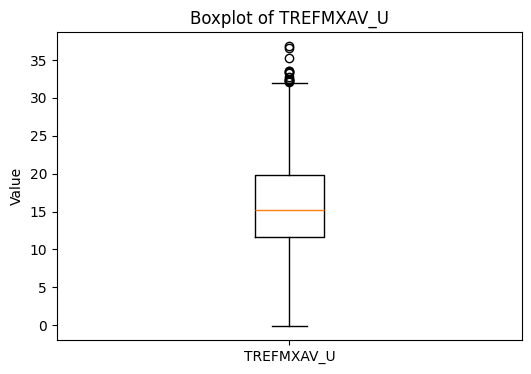

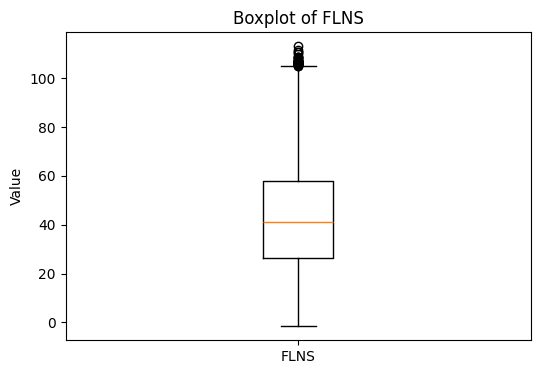

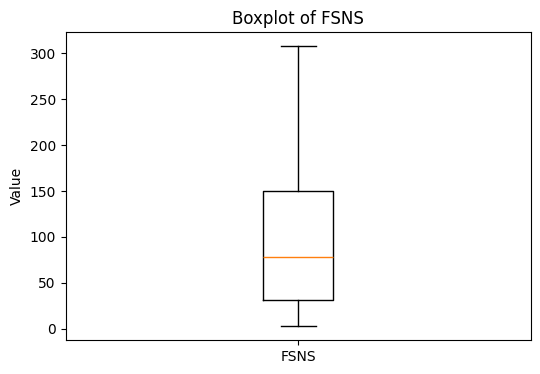

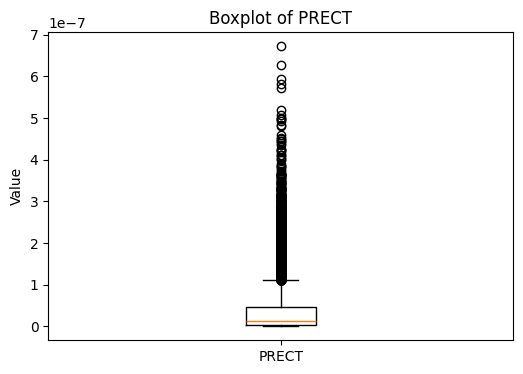

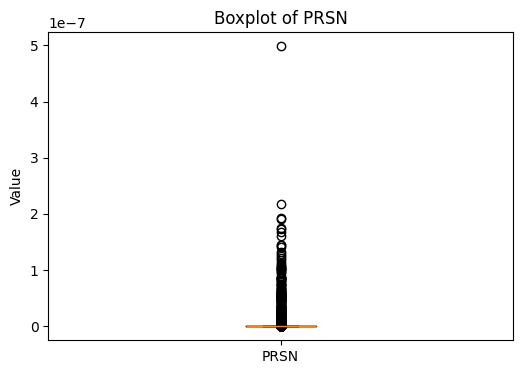

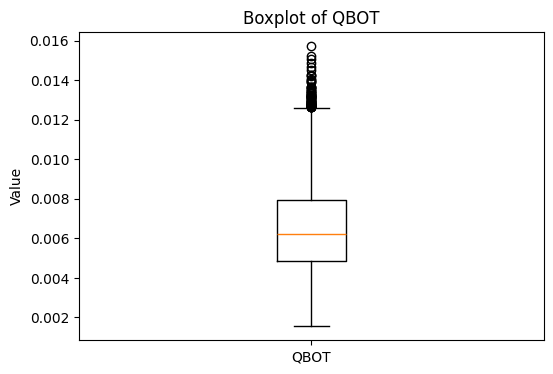

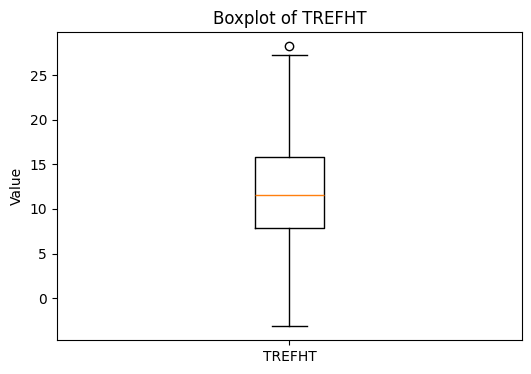

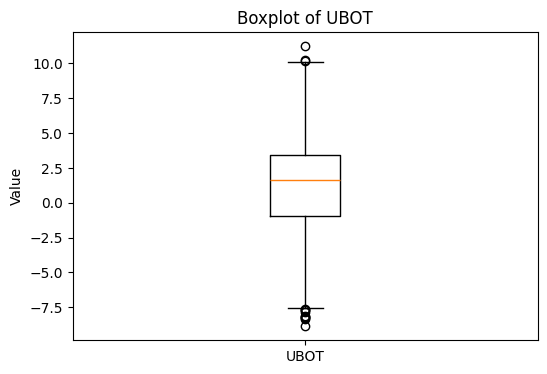

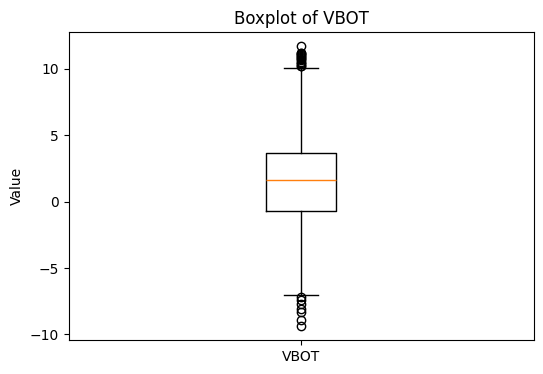

In [28]:
# Step 4: Draw a box plot (including all unprocessed data): 

cols = ['TREFMXAV_U','FLNS','FSNS','PRECT','PRSN','QBOT','TREFHT','UBOT','VBOT']

for col in cols:
    plt.figure(figsize=(6,4))
    
    plt.boxplot(df[col].dropna())
    
    # Modify the label of the x-axis
    plt.xticks([1], [col])
    
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')
    
    plt.show()

In [ ]:
# Step 5: Delete rows with significant errors

# Define the abnormal conditions for each column, as precipitation could not below zero.
error_masks = {
    'QBOT': (df['QBOT'] < 0),
    'PRECT': (df['PRECT'] < 0),
    'PRSN': (df['PRSN'] < 0),
}

# Convert to DataFrame for easier statistics
error_df = pd.DataFrame(error_masks)

# Number of abnormal values per column
print("Number of abnormal values per column:")
col_error_counts = error_df.sum()
print(col_error_counts)

# Total number of abnormal values across all columns
total_errors = col_error_counts.sum()
print("\nTotal number of abnormal values:", total_errors)

# Mark rows to delete (any column abnormal => delete row)
mask = error_df.any(axis=1)

# Print total number of rows to be deleted
print("\nTotal number of rows to be deleted:", mask.sum())

# Delete these rows
df = df[~mask]


Number of abnormal values per column:
QBOT        0
PRECT       2
PRSN     1061
dtype: int64

Total number of abnormal values: 1063

Total number of rows to be deleted: 1062


In [30]:

# Step 6: Time characteristics

df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['dayofyear'] = df['time'].dt.dayofyear

In [31]:
# Step 7:  Export
df.to_csv(r"Processed_data_manchester\008_manchester_processed.csv", index=False)

In [32]:
len(df)

26312